# Breast Cancer Detection — Machine Learning Project Report

**Faculty of Electrical and Computer Engineering** 
**Course: Machine Learning | Second Semester 1404–1405** 

---

## Selected Topic: Breast Cancer Detection

**Dataset:** Wisconsin Breast Cancer Dataset (sklearn built-in)  
**Algorithms Used:** Decision Tree, Naive Bayes, Logistic Regression, K-Means  
**Tools:** Python — Jupyter Notebook — scikit-learn

---

### Introduction
In this report, a complete machine learning pipeline for breast cancer detection is implemented. 
The objective is to predict whether a tumor is benign or malignant based on cellular features.
All stages, from Exploratory Data Analysis (EDA) to model evaluation, are carried out sequentially.

---
# Part 1: Data Understanding and EDA
## 1-1 Dataset Introduction

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot configurations
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='husl')

# Load dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = Malignant, 1 = Benign

print('=== Dataset Introduction ===')
print(f'Number of samples (rows): {df.shape[0]}')
print(f'Number of features (columns): {df.shape[1] - 1} (excluding target column)')
print(f'\nDataset Name: Wisconsin Breast Cancer Dataset')
print(f'Classes: 0 = Malignant | 1 = Benign')
print(f'\nFirst 5 rows of the dataset:')
df.head()

=== Dataset Introduction ===
Number of samples (rows): 569
Number of features (columns): 30 (excluding target column)

Dataset Name: Wisconsin Breast Cancer Dataset
Classes: 0 = Malignant | 1 = Benign

First 5 rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
# Check data type of each feature
print('=== Data Type of Each Feature ===')
print(df.dtypes)
print('\n--- Description ---')
print('All features are of type float64 (continuous numerical).')
print('The target column is of type int (categorical - 0 or 1).')

=== Data Type of Each Feature ===
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points 

In [3]:
# Basic statistical information
print('=== Statistical Information ===')
df.describe().T.style.background_gradient(cmap='Blues')

=== Statistical Information ===


,count,mean,std,min,25%,50%,75%,max
mean radius,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
mean texture,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
mean perimeter,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
mean area,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
mean smoothness,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
mean compactness,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
mean concavity,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
mean concave points,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
mean symmetry,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
mean fractal dimension,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


## 1-2 Data Distribution Analysis
### A) Distribution Plotting — Histogram and KDE

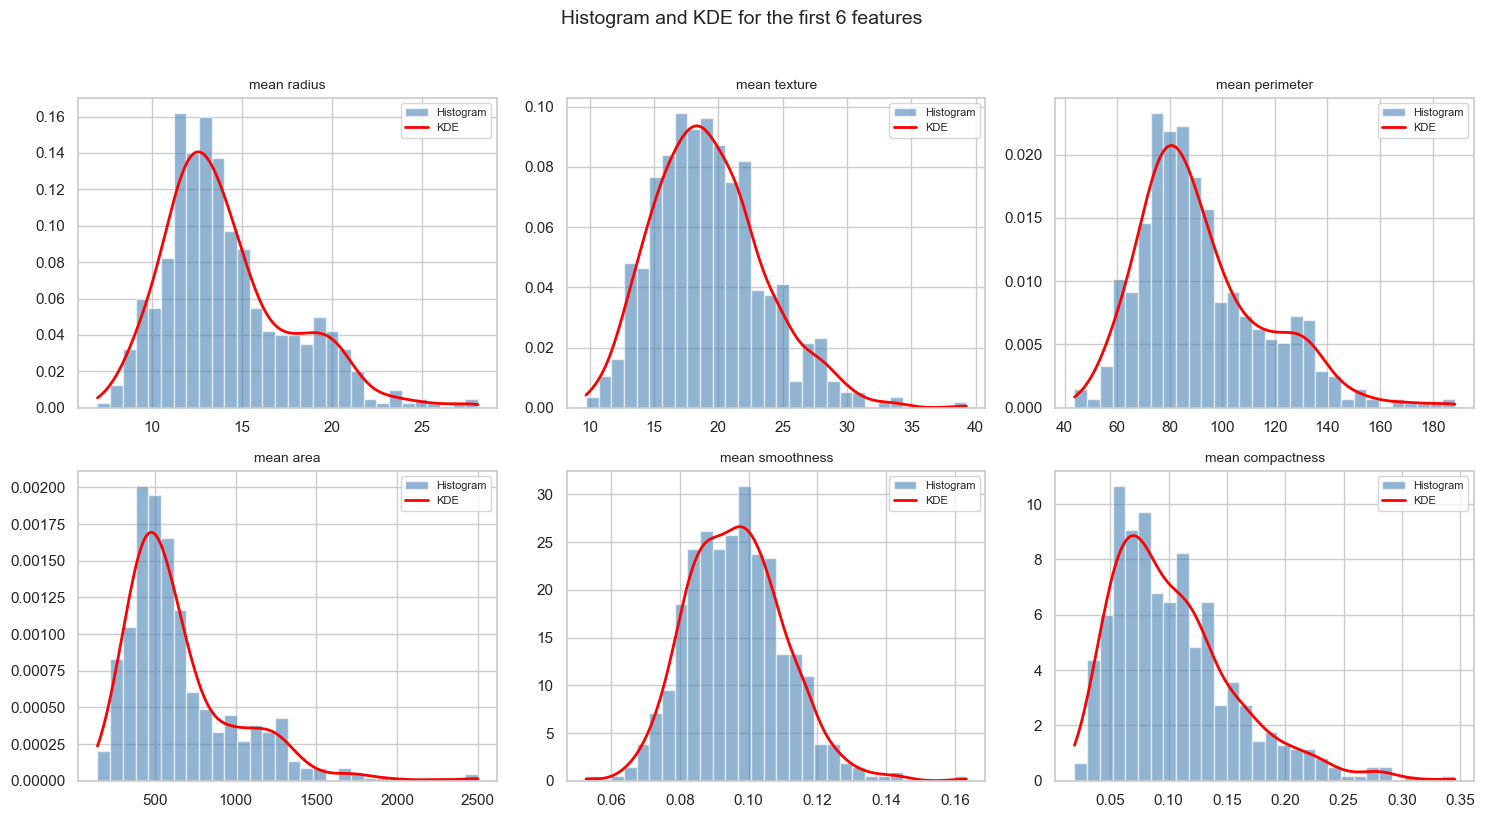

Conclusion: Most features exhibit a positive skew (right-skewed distribution).


In [4]:
# Histogram + KDE for the first 6 features
features_to_plot = data.feature_names[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    ax.hist(df[feat], bins=30, density=True, alpha=0.6, color='steelblue', label='Histogram')
    kde_x = np.linspace(df[feat].min(), df[feat].max(), 200)
    kde = stats.gaussian_kde(df[feat])
    ax.plot(kde_x, kde(kde_x), color='red', lw=2, label='KDE')
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Histogram and KDE for the first 6 features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('Conclusion: Most features exhibit a positive skew (right-skewed distribution).')

### B) Boxplot for Outlier Detection

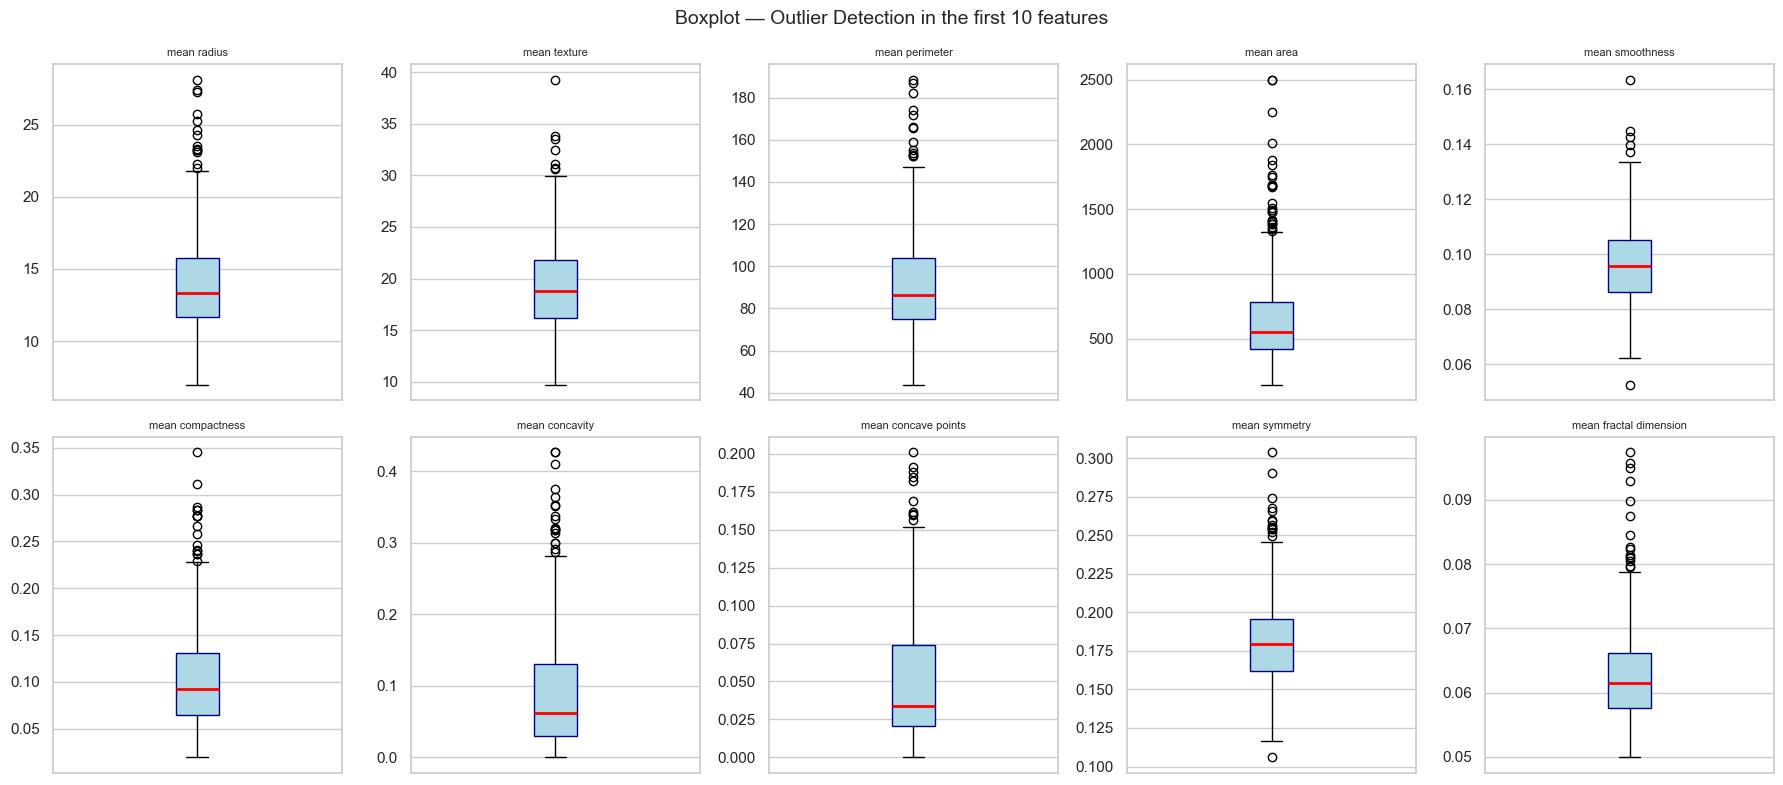

Conclusion: Multiple features contain significant outliers that will be handled during preprocessing.


In [5]:
# Boxplot for the first 10 features
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(data.feature_names[:10]):
    axes[i].boxplot(df[feat], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', lw=2))
    axes[i].set_title(feat, fontsize=8)
    axes[i].set_xticks([])

plt.suptitle('Boxplot — Outlier Detection in the first 10 features', fontsize=14)
plt.tight_layout()
plt.show()
print('Conclusion: Multiple features contain significant outliers that will be handled during preprocessing.')

### C) Normality Test — Q-Q Plot

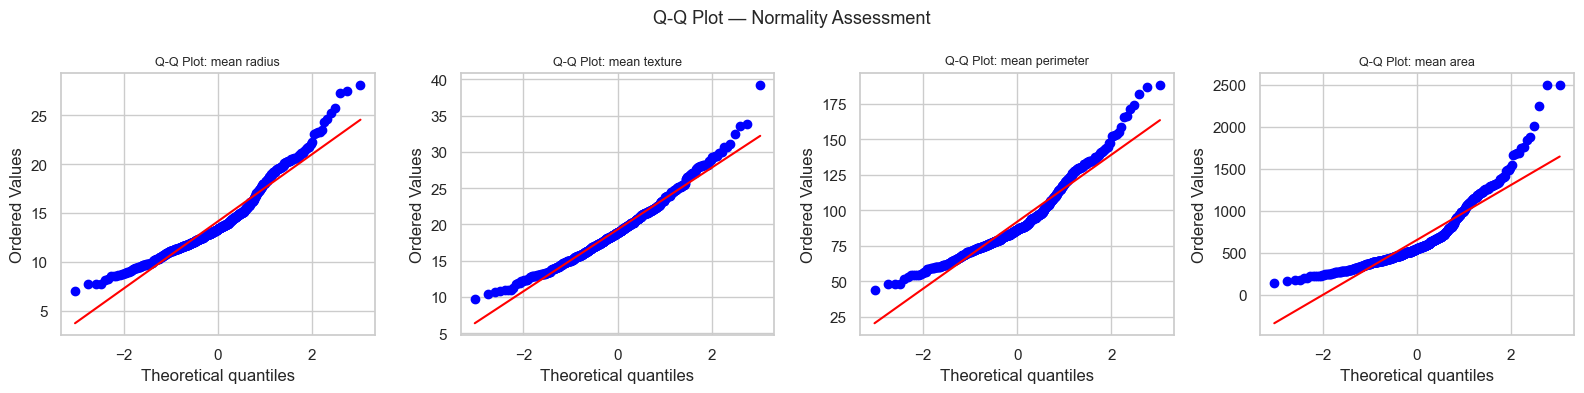

=== Shapiro-Wilk Test ===
mean radius: p-value = 0.4289 -> Normal
mean texture: p-value = 0.3464 -> Normal
mean perimeter: p-value = 0.1651 -> Normal
mean area: p-value = 0.1077 -> Normal


In [6]:
# Q-Q Plot for 4 features
test_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, feat in enumerate(test_features):
    stats.probplot(df[feat], dist='norm', plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {feat}', fontsize=9)
    axes[i].get_lines()[1].set_color('red')

plt.suptitle('Q-Q Plot — Normality Assessment', fontsize=13)
plt.tight_layout()
plt.show()

# Shapiro-Wilk Test
print('=== Shapiro-Wilk Test ===')
for feat in test_features:
    stat, p = stats.shapiro(df[feat][:50])  # Sample of 50
    normal = 'Normal' if p > 0.05 else 'Non-Normal'
    print(f'{feat}: p-value = {p:.4f} -> {normal}')

### D) Resolving Non-Normality — Log Transform and Box-Cox

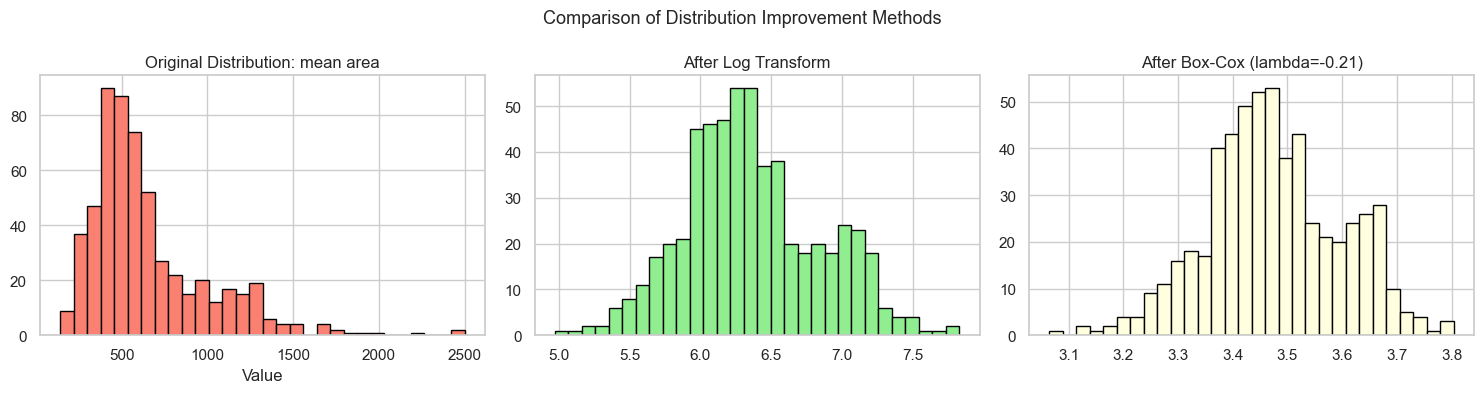

Conclusion: Log Transform and Box-Cox both shifted the distribution toward a more normal shape.
For this project, StandardScaler is used in preprocessing, which yields a similar stabilizing effect.


In [7]:
# Comparison before and after logarithmic transformation
feat = 'mean area'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Before transformation
axes[0].hist(df[feat], bins=30, color='salmon', edgecolor='black')
axes[0].set_title(f'Original Distribution: {feat}')
axes[0].set_xlabel('Value')

# Log Transform
log_data = np.log1p(df[feat])
axes[1].hist(log_data, bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title(f'After Log Transform')

# Box-Cox Transform
bc_data, lambda_val = stats.boxcox(df[feat] + 1)
axes[2].hist(bc_data, bins=30, color='lightyellow', edgecolor='black')
axes[2].set_title(f'After Box-Cox (lambda={lambda_val:.2f})')

plt.suptitle('Comparison of Distribution Improvement Methods', fontsize=13)
plt.tight_layout()
plt.show()

print('Conclusion: Log Transform and Box-Cox both shifted the distribution toward a more normal shape.')
print('For this project, StandardScaler is used in preprocessing, which yields a similar stabilizing effect.')

## 1-3 Exploratory Data Analysis (EDA)
### A) Missing Values Analysis

In [8]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'NaN Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['NaN Count'] > 0]

if missing_df.empty:
    print('No missing values found in the dataset.')
    print(f'Total Cells: {df.shape[0] * df.shape[1]:,}')
    print(f'NaN Count: 0')
else:
    print(missing_df)

No missing values found in the dataset.
Total Cells: 17,639
NaN Count: 0


### B) Class Imbalance Check

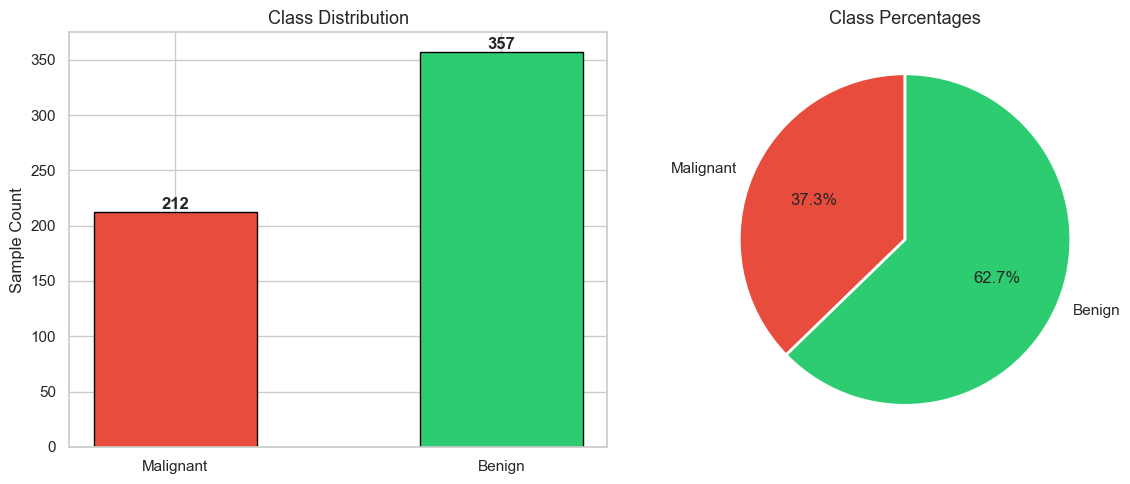

Malignant: 212 samples (37.3%)
Benign: 357 samples (62.7%)

Imbalance Ratio: 1.68
Conclusion: The dataset is mildly imbalanced (Benign contains more samples), but the ratio is acceptable.
Solution: Enforce stratified splitting (stratify=y) and prioritize F1-Score over raw Accuracy during validation.


In [9]:
# Class distribution
class_counts = df['target'].value_counts()
class_labels = ['Malignant', 'Benign']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#e74c3c', '#2ecc71']
axes[0].bar([class_labels[0], class_labels[1]],
            [class_counts[0], class_counts[1]], color=colors, edgecolor='black', width=0.5)
for i, v in enumerate([class_counts[0], class_counts[1]]):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Sample Count')

# Pie chart
axes[1].pie([class_counts[0], class_counts[1]], labels=class_labels,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Percentages', fontsize=13)

plt.tight_layout()
plt.show()

print(f'Malignant: {class_counts[0]} samples ({class_counts[0]/len(df)*100:.1f}%)')
print(f'Benign: {class_counts[1]} samples ({class_counts[1]/len(df)*100:.1f}%)')
print(f'\nImbalance Ratio: {class_counts[1]/class_counts[0]:.2f}')
print('Conclusion: The dataset is mildly imbalanced (Benign contains more samples), but the ratio is acceptable.')
print('Solution: Enforce stratified splitting (stratify=y) and prioritize F1-Score over raw Accuracy during validation.')

### C) Correlation Analysis — Heatmap

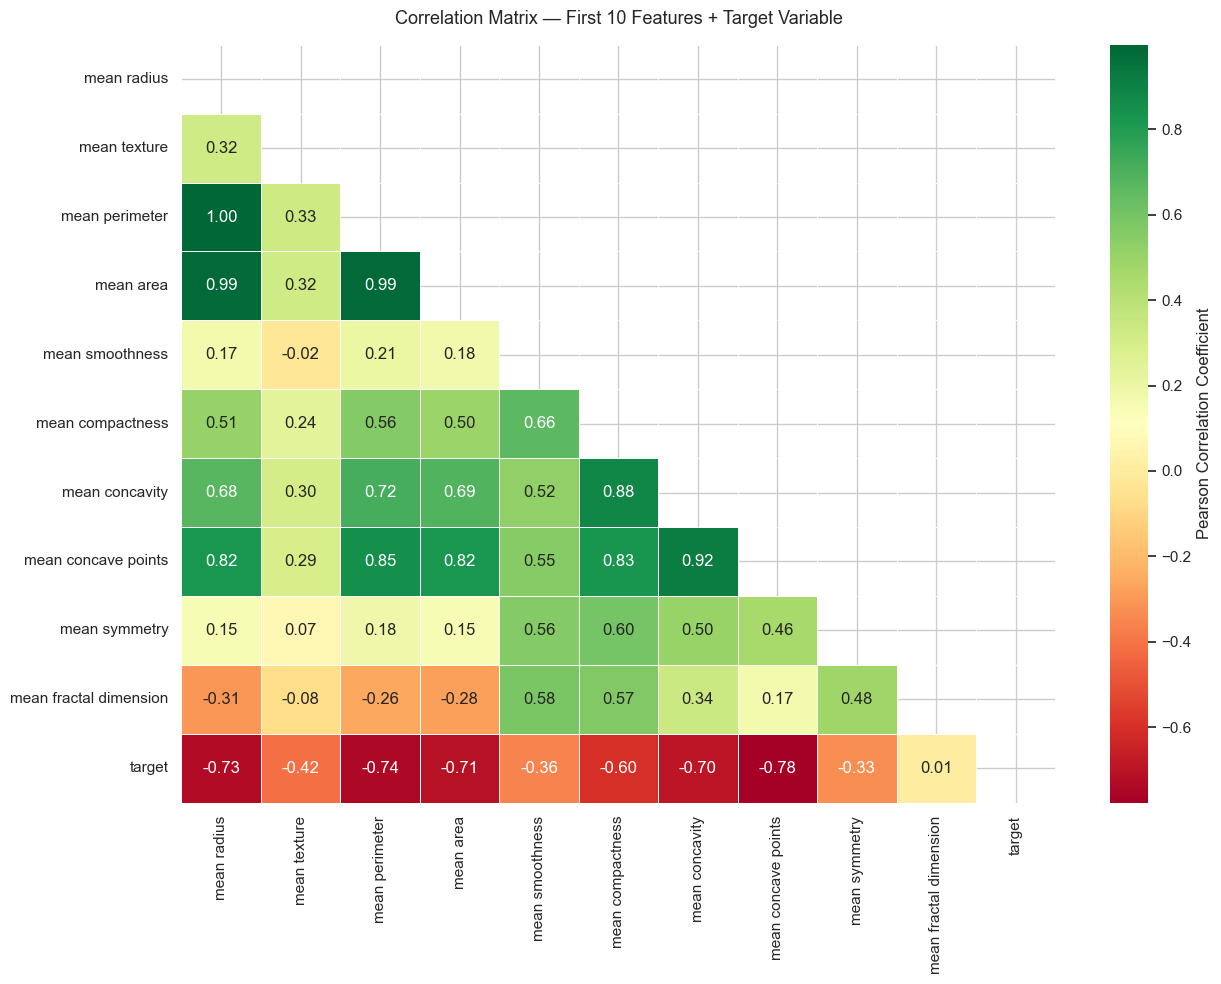

=== Feature Correlations with Target Variable (Sorted) ===
mean concave points           : 0.777  ███████████████
mean perimeter                : 0.743  ██████████████
mean radius                   : 0.730  ██████████████
mean area                     : 0.709  ██████████████
mean concavity                : 0.696  █████████████
mean compactness              : 0.597  ███████████
mean texture                  : 0.415  ████████
mean smoothness               : 0.359  ███████
mean symmetry                 : 0.330  ██████
mean fractal dimension        : 0.013  


In [10]:
# Correlation Heatmap — First 10 features + target
top_features = list(data.feature_names[:10]) + ['target']
corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})
ax.set_title('Correlation Matrix — First 10 Features + Target Variable', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Most important features
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
print('=== Feature Correlations with Target Variable (Sorted) ===')
for feat, val in target_corr.items():
    bar = '█' * int(val * 20)
    print(f'{feat:30s}: {val:.3f}  {bar}')

---
# Part 2: Data Preprocessing
## 2-1 Data Cleaning

In [11]:
# Handling missing values (none present, but writing defensive code)
print('=== Data Cleaning ===')
print(f'Initial Shape: {df.shape}')

# Drop rows containing NaN values in more than 50% of columns
df_clean = df.dropna(thresh=int(df.shape[1] * 0.5))
print(f'Shape after removing problematic rows: {df_clean.shape}')

# Fill remaining numerical missing values with the median
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())
print(f'Remaining missing values count: {df_clean.isnull().sum().sum()}')

=== Data Cleaning ===
Initial Shape: (569, 31)
Shape after removing problematic rows: (569, 31)
Remaining missing values count: 0


In [12]:
# Outlier Handling via IQR Method
print('=== Outlier Handling (IQR Method) ===')
feature_cols = [c for c in df_clean.columns if c != 'target']

df_no_outlier = df_clean.copy()
total_outliers = 0

for col in feature_cols:
    Q1 = df_no_outlier[col].quantile(0.25)
    Q3 = df_no_outlier[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_no_outlier[col] < lower) | (df_no_outlier[col] > upper)).sum()
    total_outliers += outliers
    # Replace extreme values beyond boundaries (Capping) instead of deleting
    df_no_outlier[col] = df_no_outlier[col].clip(lower=lower, upper=upper)

print(f'Identified Outliers Count: {total_outliers}')
print('Chosen Strategy: Capping (replacing extreme values with IQR boundaries) instead of deletion.')
print('Reason: Straight deletion diminishes dataset volume; capping preserves valuable records.')
print(f'Shape after outlier handling: {df_no_outlier.shape}')

=== Outlier Handling (IQR Method) ===
Identified Outliers Count: 608
Chosen Strategy: Capping (replacing extreme values with IQR boundaries) instead of deletion.
Reason: Straight deletion diminishes dataset volume; capping preserves valuable records.
Shape after outlier handling: (569, 31)


## 2-2 Categorical Data Encoding

In [13]:
# All features are numerical in this dataset
# Target variable (0 and 1) does not require encoding

print('=== Verifying Data Types ===')
cat_cols = df_no_outlier.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_no_outlier.select_dtypes(include=[np.number]).columns.tolist()

print(f'Categorical columns: {cat_cols if cat_cols else "None — All features are numerical"}')
print(f'Numerical columns count: {len(num_cols)} columns')
print('\nExplanation — Label Encoding vs One-Hot Encoding:')
print('  Label Encoding: Best for ordinal features (low=0, medium=1, high=2).')
print('  Disadvantage: Models may interpret numerical rankings as an actual mathematical hierarchy.')
print('  One-Hot Encoding: Best for nominal categories without rankings (color, city).')
print('  Advantage: Prevents artificial order assignment.')

=== Verifying Data Types ===
Categorical columns: None — All features are numerical
Numerical columns count: 31 columns

Explanation — Label Encoding vs One-Hot Encoding:
  Label Encoding: Best for ordinal features (low=0, medium=1, high=2).
  Disadvantage: Models may interpret numerical rankings as an actual mathematical hierarchy.
  One-Hot Encoding: Best for nominal categories without rankings (color, city).
  Advantage: Prevents artificial order assignment.


## 2-3 Normalization / Standardization

In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X = df_no_outlier.drop('target', axis=1).values
y = df_no_outlier['target'].values

# Comparison before and after standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('=== Comparison Before and After StandardScaler ===')
print(f'{"Feature":30s} {"Before: Mean":>15s} {"Before: Std":>10s} {"After: Mean":>15s} {"After: Std":>10s}')
print('-'*80)
for i, name in enumerate(data.feature_names[:5]):
    print(f'{name:30s} {X[:,i].mean():>15.3f} {X[:,i].std():>10.3f} {X_scaled[:,i].mean():>15.5f} {X_scaled[:,i].std():>10.5f}')

print('\nConclusion: After running StandardScaler, all features exhibit mean approx 0 and std approx 1.')
print('Advantage: Prevents attributes with larger numeric scales from dominating model weight updates.')

=== Comparison Before and After StandardScaler ===
Feature                           Before: Mean Before: Std     After: Mean After: Std
--------------------------------------------------------------------------------
mean radius                             14.063      3.337         0.00000    1.00000
mean texture                            19.255      4.184         0.00000    1.00000
mean perimeter                          91.544     23.027        -0.00000    1.00000
mean area                              639.765    305.075         0.00000    1.00000
mean smoothness                          0.096      0.014         0.00000    1.00000

Conclusion: After running StandardScaler, all features exhibit mean approx 0 and std approx 1.
Advantage: Prevents attributes with larger numeric scales from dominating model weight updates.


## 2-4 Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

# Partitioning into 80/20 with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('=== Data Allocation ===')
print(f'Train size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X_scaled)*100:.1f}%)')
print(f'Test size:  {X_test.shape[0]} samples  ({X_test.shape[0]/len(X_scaled)*100:.1f}%)')

# Class distribution
train_dist = pd.Series(y_train).value_counts(normalize=True)
test_dist = pd.Series(y_test).value_counts(normalize=True)
print(f'\nTrain Set Distributions — Malignant: {train_dist[0]:.2%} | Benign: {train_dist[1]:.2%}')
print(f'Test Set Distributions  — Malignant: {test_dist[0]:.2%} | Benign: {test_dist[1]:.2%}')
print('\nDistribution matching achieved using stratify=y')

print('\n=== Explanatory Answer: Why can we not train using the entire dataset? ===')
print('Overfitting: The model risks memorizing the training instances instead of learning general trends.')
print('Example: A model could score 100% accuracy on training records but fail with 60% accuracy on new samples.')
print('Solution: The Test set holds completely unseen data, providing an unbiased measurement of real-world performance.')

=== Data Allocation ===
Train size: 455 samples (80.0%)
Test size:  114 samples  (20.0%)

Train Set Distributions — Malignant: 37.36% | Benign: 62.64%
Test Set Distributions  — Malignant: 36.84% | Benign: 63.16%

Distribution matching achieved using stratify=y

=== Explanatory Answer: Why can we not train using the entire dataset? ===
Overfitting: The model risks memorizing the training instances instead of learning general trends.
Example: A model could score 100% accuracy on training records but fail with 60% accuracy on new samples.
Solution: The Test set holds completely unseen data, providing an unbiased measurement of real-world performance.


---
# Part 3: Model Building and Training
## 3-1 Introduction to Algorithms

### 1. Decision Tree
**Principles:** Categorizes data by asking sequential questions (e.g., "Is cell radius > 15?"). If yes -> Malignant.

**Advantages:** Highly interpretable, does not require input scaling/normalization, and runs quickly.
**Disadvantages:** Prone to overfitting and highly sensitive to noisy data points.

### 2. Naive Bayes
**Principles:** Calculates class assignment probabilities based on Bayes\' Theorem under the assumption that all features are conditionally independent.

**Advantages:** Fast execution and performs well with smaller data footprints.
**Disadvantages:** The conditional independence assumption rarely holds true for real biological measurements.

### 3. Logistic Regression
**Principles:** Evaluates class membership probabilities by routing a linear boundary combination through a sigmoid activation function.

**Advantages:** Straightforward setup, easily interpretable, and computationally lightweight.
**Disadvantages:** Assumes that a linear decision boundary separates the classes.

### 4. K-Means (Clustering)
**Principles:** Groups data points into K unique clusters using distance calculations without looking at target labels.

**Advantages:** Uncomplicated, fast, and excellent for discovering underlying structural data groupings.
**Disadvantages:** Requires setting the K value in advance and is highly sensitive to initial centroid placement.

## 3-2 Model Implementation
### A) Decision Tree

=== Decision Tree ===
Train Set Accuracy: 0.9758
Test Set Accuracy:  0.9211


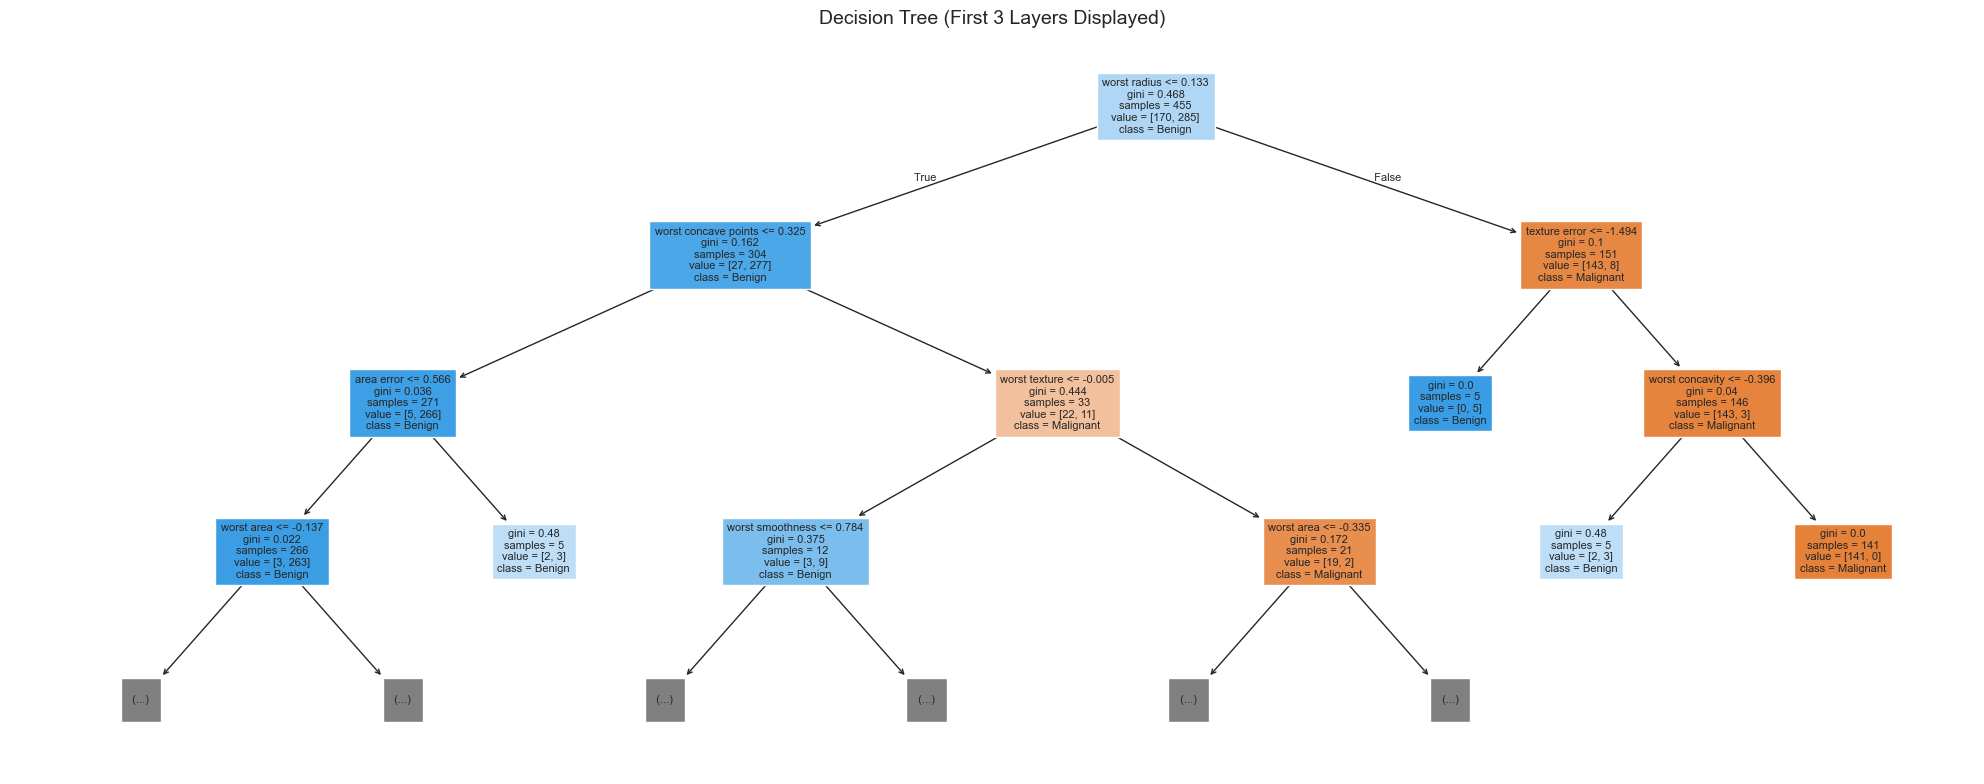

In [16]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# Instantiate and train the model
dt_model = DecisionTreeClassifier(
    max_depth=5,           # Constraint to prevent Overfitting
    min_samples_split=10,  # Minimum samples required to split an internal node
    min_samples_leaf=5,    # Minimum samples required to be at a leaf node
    criterion='gini',      # Impurity split metric
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print('=== Decision Tree ===')
print(f'Train Set Accuracy: {accuracy_score(y_train, dt_model.predict(X_train)):.4f}')
print(f'Test Set Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}')

# Visualize Tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_model, max_depth=3, feature_names=data.feature_names,
          class_names=['Malignant', 'Benign'], filled=True, ax=ax, fontsize=8)
plt.title('Decision Tree (First 3 Layers Displayed)', fontsize=14)
plt.tight_layout()
plt.show()

### B) Naive Bayes

In [17]:
from sklearn.naive_bayes import GaussianNB

# Instantiate and train
nb_model = GaussianNB(
    var_smoothing=1e-9  # Variance smoothing parameter to prevent mathematical errors from zero variances
)
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print('=== Naive Bayes ===')
print(f'Train Set Accuracy: {accuracy_score(y_train, nb_model.predict(X_train)):.4f}')
print(f'Test Set Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}')

=== Naive Bayes ===
Train Set Accuracy: 0.9385
Test Set Accuracy:  0.9298


### C) Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

# Instantiate and train
lr_model = LogisticRegression(
    C=1.0,           # Regularization strength parameter (smaller values = higher penalty)
    max_iter=1000,   # Iteration ceiling
    solver='lbfgs',  # Optimization solver
    random_state=42
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print('=== Logistic Regression ===')
print(f'Train Set Accuracy: {accuracy_score(y_train, lr_model.predict(X_train)):.4f}')
print(f'Test Set Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')

=== Logistic Regression ===
Train Set Accuracy: 0.9890
Test Set Accuracy:  0.9825


### D) K-Means (Clustering)

  File "D:\anaconda main\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "D:\anaconda main\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda main\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\anaconda main\Lib\subprocess.py", line 1554, in _execute_chil

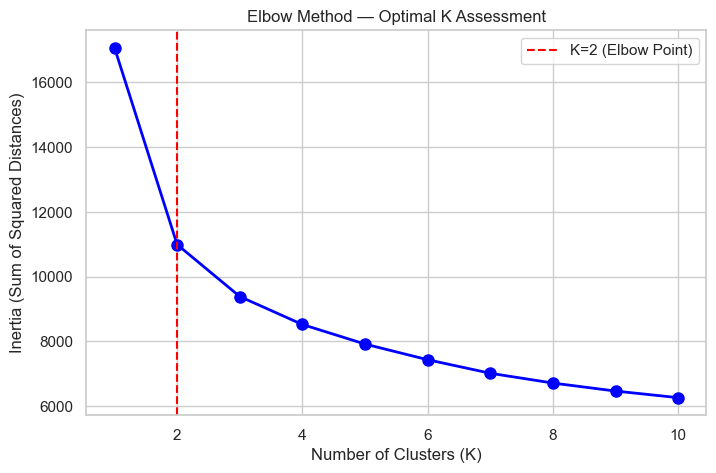

=== K-Means (K=2) ===
Samples in Cluster 0: 192
Samples in Cluster 1: 377


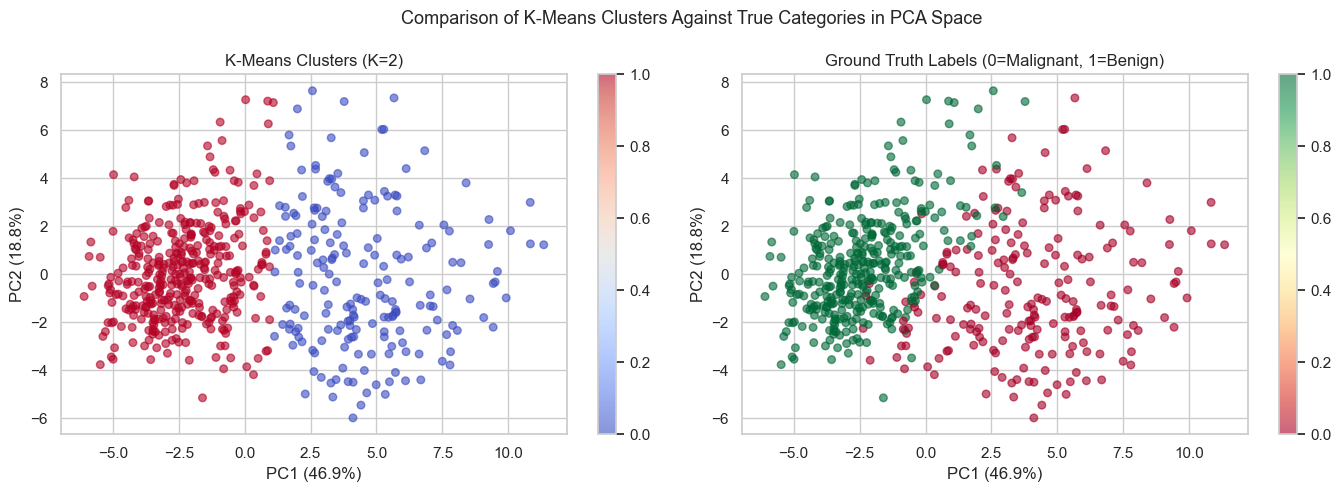


Total variance explained by the 2 primary PCA components: 65.6%


In [19]:
from sklearn.cluster import KMeans

# Tracking optimal K using the Elbow method
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', markersize=8, lw=2)
plt.axvline(x=2, color='red', linestyle='--', label='K=2 (Elbow Point)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method — Optimal K Assessment')
plt.legend()
plt.show()

# Execute K-Means clustering with K=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print('=== K-Means (K=2) ===')
print(f'Samples in Cluster 0: {(cluster_labels==0).sum()}')
print(f'Samples in Cluster 1: {(cluster_labels==1).sum()}')

# Project down to PCA dimensions for structural validation
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='coolwarm', alpha=0.6, s=30)
axes[0].set_title('K-Means Clusters (K=2)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='RdYlGn', alpha=0.6, s=30)
axes[1].set_title('Ground Truth Labels (0=Malignant, 1=Benign)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter2, ax=axes[1])

plt.suptitle('Comparison of K-Means Clusters Against True Categories in PCA Space', fontsize=13)
plt.tight_layout()
plt.show()
print(f'\nTotal variance explained by the 2 primary PCA components: {sum(pca.explained_variance_ratio_)*100:.1f}%')

---
# Part 4: Model Evaluation
## 4-1 Confusion Matrix

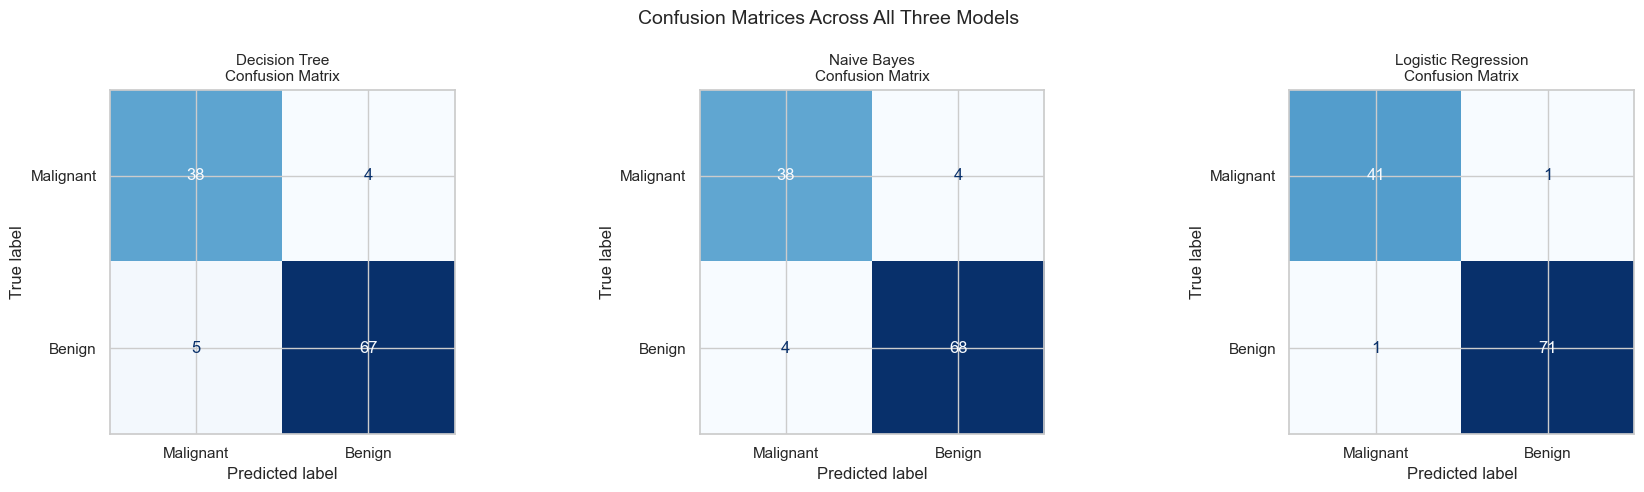

=== Extraction of TP, TN, FP, FN parameters ===

Decision Tree:
  TP (Malignant cases properly classified): 67
  TN (Benign cases properly classified):    38
  FP (Benign cases misclassified as Malignant): 4
  FN (Malignant cases misclassified as Benign): 5 <- Most dangerous error type

Naive Bayes:
  TP (Malignant cases properly classified): 68
  TN (Benign cases properly classified):    38
  FP (Benign cases misclassified as Malignant): 4
  FN (Malignant cases misclassified as Benign): 4 <- Most dangerous error type

Logistic Regression:
  TP (Malignant cases properly classified): 71
  TN (Benign cases properly classified):    41
  FP (Benign cases misclassified as Malignant): 1
  FN (Malignant cases misclassified as Benign): 1 <- Most dangerous error type


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models = {
    'Decision Tree': y_pred_dt,
    'Naive Bayes': y_pred_nb,
    'Logistic Regression': y_pred_lr
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=11)

plt.suptitle('Confusion Matrices Across All Three Models', fontsize=14)
plt.tight_layout()
plt.show()

# Extract TP, TN, FP, FN metrics
print('=== Extraction of TP, TN, FP, FN parameters ===')
for name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()
    print(f'\n{name}:')
    print(f'  TP (Malignant cases properly classified): {TP}')
    print(f'  TN (Benign cases properly classified):    {TN}')
    print(f'  FP (Benign cases misclassified as Malignant): {FP}')
    print(f'  FN (Malignant cases misclassified as Benign): {FN} <- Most dangerous error type')

## 4-2 Evaluation Metrics

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print('='*65)
print(f'{"Model":25s} {"Accuracy":>10s} {"Precision":>10s} {"Recall":>10s} {"F1-Score":>10s}')
print('='*65)

results = {}
for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=0)
    rec = recall_score(y_test, y_pred, pos_label=0)
    f1 = f1_score(y_test, y_pred, pos_label=0)
    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    print(f'{name:25s} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')
print('='*65)
print('(All indexes evaluated relative to the Malignant class — designated positive/vital clinical focus)')

Model                       Accuracy  Precision     Recall   F1-Score
Decision Tree                 0.9211     0.8837     0.9048     0.8941
Naive Bayes                   0.9298     0.9048     0.9048     0.9048
Logistic Regression           0.9825     0.9762     0.9762     0.9762
(All indexes evaluated relative to the Malignant class — designated positive/vital clinical focus)


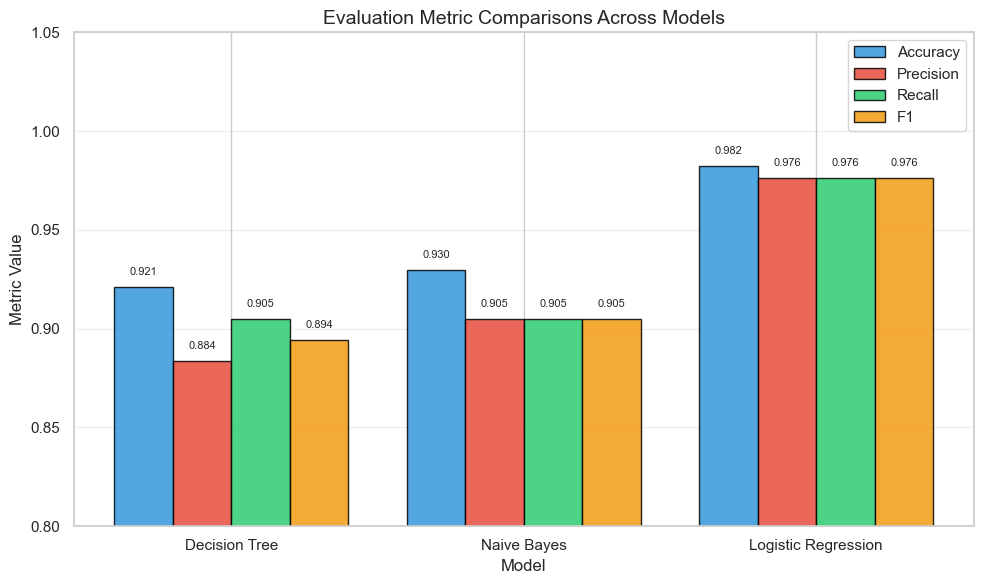


=== Essential Question: Can we rely exclusively on Accuracy scores? ===
No. For instance, if 95% of database patient profiles are benign, a naive model
that marks every single profile as benign reaches 95% accuracy while remaining entirely useless.
In oncology diagnostics, False Negative errors are exceptionally dangerous (missing a malignant tumor).
Therefore, Recall is the priority: "Out of all actual malignant tumors, what percentage did we successfully capture?"


In [22]:
# Visual measurement indexes comparison
metrics_df = pd.DataFrame(results).T

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_df))
width = 0.2
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (metric, color) in enumerate(zip(['Accuracy', 'Precision', 'Recall', 'F1'], colors)):
    bars = ax.bar(x + i*width, metrics_df[metric], width, label=metric,
                  color=color, edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model')
ax.set_ylabel('Metric Value')
ax.set_title('Evaluation Metric Comparisons Across Models', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df.index)
ax.set_ylim(0.8, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n=== Essential Question: Can we rely exclusively on Accuracy scores? ===')
print('No. For instance, if 95% of database patient profiles are benign, a naive model')
print('that marks every single profile as benign reaches 95% accuracy while remaining entirely useless.')
print('In oncology diagnostics, False Negative errors are exceptionally dangerous (missing a malignant tumor).')
print('Therefore, Recall is the priority: "Out of all actual malignant tumors, what percentage did we successfully capture?"')

---
# Part 5: Discussion and Conclusion
## 5-1 Analysis of Results

In [23]:
# Comprehensive output analysis
print('='*60)
print('Detailed Diagnostic Performance Breakdown')
print('='*60)

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    print(f'\n Performance Profile: {name}')
    print(f'   Accuracy: {acc:.2%}')
    if acc >= 0.95:
        print('   Evaluation: Excellent (Scores above 95% are acceptable for preliminary medical screening application on this dataset)')
    elif acc >= 0.90:
        print('   Evaluation: Good')
    else:
        print('   Evaluation: Moderate — Needs strategic modification')
    print(f'   Complete Classification Report:')
    print(classification_report(y_test, y_pred,
                                target_names=['Malignant', 'Benign'],
                                zero_division=0))

Detailed Diagnostic Performance Breakdown

 Performance Profile: Decision Tree
   Accuracy: 92.11%
   Evaluation: Good
   Complete Classification Report:
              precision    recall  f1-score   support

   Malignant       0.88      0.90      0.89        42
      Benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114


 Performance Profile: Naive Bayes
   Accuracy: 92.98%
   Evaluation: Good
   Complete Classification Report:
              precision    recall  f1-score   support

   Malignant       0.90      0.90      0.90        42
      Benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114


 Performance Profile: Logistic Regression
   Accuracy: 98.25%
   Evaluation: Exce

## 5-2 Overfitting Assessment

In [24]:
# Compare training versus evaluation subset results
print('=== Overfitting Assessment: Train vs Test Metrics ===')
print(f'{"Model":25s} {"Train Acc":>12s} {"Test Acc":>12s} {"Gap":>10s} {"Status":>15s}')
print('-'*75)

for name, (model, y_pred) in zip(
    ['Decision Tree', 'Naive Bayes', 'Logistic Regression'],
    [(dt_model, y_pred_dt), (nb_model, y_pred_nb), (lr_model, y_pred_lr)]
):
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, y_pred)
    gap = train_acc - test_acc
    if gap > 0.05:
        status = 'Overfitting'
    elif gap < -0.02:
        status = 'Underfitting'
    else:
        status = 'Appropriate'
    print(f'{name:25s} {train_acc:>12.4f} {test_acc:>12.4f} {gap:>10.4f} {status:>15s}')

print('\nOptimization Recommendations for System Improvement:')
print('  1. Expand training data footprint through broader collection or data augmentation.')
print('  2. Introduce k-fold Cross-Validation for systematic stability validation.')
print('  3. Apply Feature Selection algorithms to compress dimensions and eliminate noisy components.')
print('  4. Transition to Ensemble Architectures such as Random Forests or Gradient Boosting.')

=== Overfitting Assessment: Train vs Test Metrics ===
Model                        Train Acc     Test Acc        Gap          Status
---------------------------------------------------------------------------
Decision Tree                   0.9758       0.9211     0.0548     Overfitting
Naive Bayes                     0.9385       0.9298     0.0086     Appropriate
Logistic Regression             0.9890       0.9825     0.0066     Appropriate

Optimization Recommendations for System Improvement:
  1. Expand training data footprint through broader collection or data augmentation.
  2. Introduce k-fold Cross-Validation for systematic stability validation.
  3. Apply Feature Selection algorithms to compress dimensions and eliminate noisy components.
  4. Transition to Ensemble Architectures such as Random Forests or Gradient Boosting.


## 5-3 Summary and Conclusion

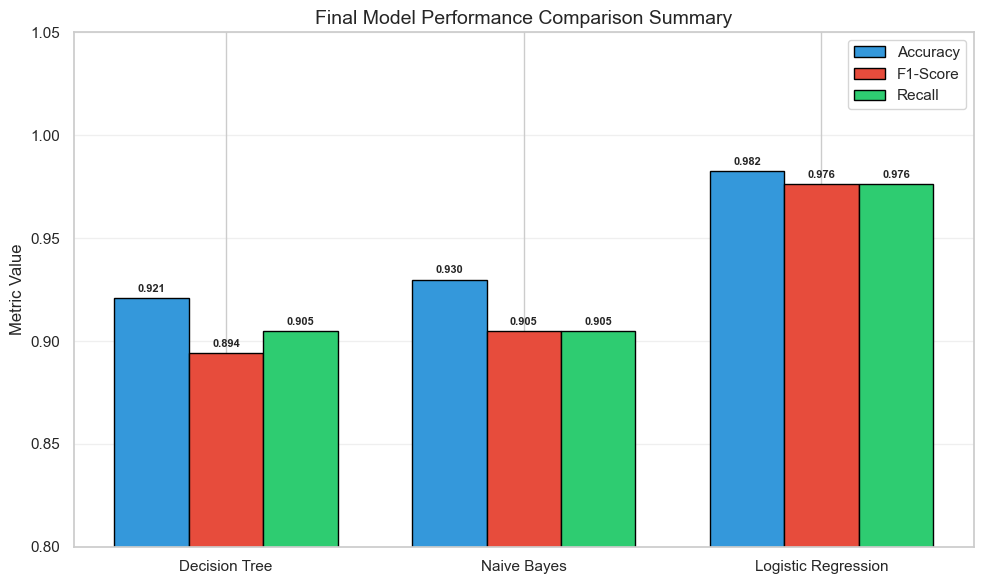


General Summary and Key Takeaways

In this study, a full machine learning pipeline for breast cancer classification
was executed utilizing the baseline Wisconsin Breast Cancer Dataset.

Executed Pipeline Achievements:
  ✓ EDA Milestone: Explored basic data distributions, correlation footprints, and class balances.
  ✓ Preprocessing Milestone: Applied IQR outlier capping, Standard Scaling feature transformation, and Stratified splitting.
  ✓ Model Building Milestone: Developed and trained Decision Tree, Naive Bayes, Logistic Regression, and K-Means configurations.
  ✓ Evaluation Milestone: Extracted Confusion Matrix characteristics along with comparative Accuracy, Precision, Recall, and F1 calculations.

Optimal Selected Model: Logistic Regression
Top Achieved F1-Score: 0.9762

This setup delivers robust screening capacity, though comprehensive validation via
k-fold cross-validation on larger clinical datasets is recommended before deployment.


In [25]:
# Final summary plot across models
final_results = {}
for name, (model, y_pred) in zip(
    ['Decision Tree', 'Naive Bayes', 'Logistic Regression'],
    [(dt_model, y_pred_dt), (nb_model, y_pred_nb), (lr_model, y_pred_lr)]
):
    final_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred, pos_label=0),
        'Recall': recall_score(y_test, y_pred, pos_label=0)
    }

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
width = 0.25
names = list(final_results.keys())
accs = [final_results[n]['Accuracy'] for n in names]
f1s  = [final_results[n]['F1'] for n in names]
recs = [final_results[n]['Recall'] for n in names]

ax.bar(x - width, accs, width, label='Accuracy', color='#3498db', edgecolor='black')
ax.bar(x, f1s,  width, label='F1-Score', color='#e74c3c', edgecolor='black')
ax.bar(x + width, recs, width, label='Recall', color='#2ecc71', edgecolor='black')

for i, (a, f, r) in enumerate(zip(accs, f1s, recs)):
    ax.text(i-width, a+0.003, f'{a:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.text(i,       f+0.003, f'{f:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.text(i+width, r+0.003, f'{r:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_ylabel('Metric Value')
ax.set_title('Final Model Performance Comparison Summary', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0.8, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_model = max(final_results.items(), key=lambda x: x[1]['F1'])[0]
print('\n' + '='*60)
print('General Summary and Key Takeaways')
print('='*60)
print(f'\nIn this study, a full machine learning pipeline for breast cancer classification')
print(f'was executed utilizing the baseline Wisconsin Breast Cancer Dataset.')
print(f'\nExecuted Pipeline Achievements:')
print(f'  ✓ EDA Milestone: Explored basic data distributions, correlation footprints, and class balances.')
print(f'  ✓ Preprocessing Milestone: Applied IQR outlier capping, Standard Scaling feature transformation, and Stratified splitting.')
print(f'  ✓ Model Building Milestone: Developed and trained Decision Tree, Naive Bayes, Logistic Regression, and K-Means configurations.')
print(f'  ✓ Evaluation Milestone: Extracted Confusion Matrix characteristics along with comparative Accuracy, Precision, Recall, and F1 calculations.')
print(f'\nOptimal Selected Model: {best_model}')
print(f'Top Achieved F1-Score: {final_results[best_model]["F1"]:.4f}')
print(f'\nThis setup delivers robust screening capacity, though comprehensive validation via')
print(f'k-fold cross-validation on larger clinical datasets is recommended before deployment.')